### Deep learning model training.


In [3]:
import time
import torch
import random
import numpy as np 
import pandas as pd 
import torch.nn as nn
from glob import glob
from pyrsimg import imsShow
from notebooks import config
import matplotlib.pyplot as plt
from utils.utils import read_scenes   
from torchvision.transforms import v2
from utils.data_loader import GaussianNoise
from utils.data_loader import SceneArraySet, PatchPathSet
from torchmetrics.classification import MulticlassJaccardIndex, BinaryAccuracy
from model import unet, deeplabv3plus_mobilev2


In [4]:
patch_size = 512  ## patch size setting
patch_resize = None  ## patch resize setting
model_name = 'unet' 
learning_rate = 1e-4
batch_size = 4
### traset
paths_scene_tra, paths_dem_tra, paths_truth_tra = config.paths_tra_scene,  \
                                          config.paths_tra_dem, config.paths_tra_truth
print(f'train scenes: {len(paths_scene_tra)}')
## valset
paths_valset = sorted(glob(f'data/dset/dset_split/val_patch/patch_{patch_size}/*'))  ## for model prediction 
print(f'vali patch {patch_size}: {len(paths_valset)}')


train scenes: 52
vali patch 512: 208


### dataset loading

In [5]:
scenes_arr, dems_arr, truths_arr = read_scenes(paths_scene_tra, paths_dem_tra, paths_truth_tra)     
scene_dem_truth_ls =  list(zip(scenes_arr, dems_arr, truths_arr))
scene_dem_truth_ls = [np.concatenate([scene, dem, truth[:, :, np.newaxis]], axis=-1) 
                            for scene, dem, truth in scene_dem_truth_ls]    

In [6]:
# scenes_arr, truths_arr = read_scenes(paths_scene_tra, paths_truth_tra) 
# scene_truth_ls =  list(zip(scenes_arr, truths_arr))
# scene_truth_ls = [np.concatenate([scene, truth[:, :, np.newaxis]], axis=-1) 
#                               for scene, truth in scene_truth_ls] 


In [7]:
transforms_tra = v2.Compose([
      v2.ToImage(),
      v2.RandomCrop(size=(patch_size, patch_size)),
      v2.RandomApply([v2.RandomRotation(degrees=15)], p=0.5),
      v2.RandomHorizontalFlip(p=0.5),
      v2.RandomVerticalFlip(p=0.5),
      GaussianNoise(mean=0, sigma_max=0.05, p=0.5)    
       ])
transforms_val = v2.Compose([
      v2.ToDtype(torch.float32),
       ]) 


In [8]:
tra_dset = SceneArraySet(scene_dem_truth_list = scene_dem_truth_ls, 
                            transforms = transforms_tra)
val_dset = PatchPathSet(paths_valset=paths_valset, 
                            transforms=transforms_val)
print(len(tra_dset), len(val_dset))


52 208


In [9]:
### Create DataLoader
tra_loader = torch.utils.data.DataLoader(tra_dset, 
                                         batch_size=batch_size, 
                                         shuffle=True, 
                                         num_workers=4)
val_loader = torch.utils.data.DataLoader(val_dset, 
                                         batch_size=batch_size,
                                         num_workers=4) 


#### Model training

In [10]:
### check model
model = unet(num_bands=7)
# model = deeplabv3plus_mobilev2(num_bands=7)  


In [11]:
input_tensor = torch.randn(2, 7, 512, 512)  
output = model(input_tensor) 
print(output.shape)


torch.Size([2, 1, 512, 512])


In [12]:
### create loss and optimizer
loss_bce = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)  
# lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, \
#                                       mode='min', 
#                                       factor=0.5, 
#                                       patience=10,
#                                       min_lr=1e-5)


In [13]:
sam_index = random.randrange(len(val_dset))
patch_val, truth_val = val_dset[sam_index]
def show_result(model, patch, truth):
    model.eval()
    device = next(model.parameters()).device
    patch, truth = patch.unsqueeze(0).to(device), truth.to(device)
    pred = model(patch) 
    ## convert to numpy and plot
    patch = patch[0].to('cpu').detach().numpy().transpose(1,2,0)            
    pred = pred[0].to('cpu').detach().numpy()
    truth = truth.to('cpu').detach().numpy()
    imsShow([patch, pred, truth],   
            clip_list = (2,0,0),
            img_name_list=['patch', 'pred', 'truth'], 
            color_bands_list=([3,2,2], 0, 0),                    
            figsize=(9, 2.5))
    plt.tight_layout() 
    plt.show() 



In [ ]:
## 5. train and val loops
'''------train loops------'''
def train_loops(model, loss_fn, 
                    optimizer, 
                    tra_loader, 
                    val_loader,  
                    epoches, 
                    device, 
                    lr_scheduler=None):
    loss_tra_loops, miou_tra_loops, oa_tra_loops = [], [], []
    loss_val_loops, miou_val_loops, oa_val_loops = [], [], []
    model = model.to(device)
    size_tra_loader = len(tra_loader)
    size_val_loader = len(val_loader)
    best_miou = 0.90
    epoches_i = []
    for epoch in range(epoches):
        start = time.time()
        loss_tra, loss_val = 0, 0
        '''-----train the model-----'''
        oa_tra = BinaryAccuracy().to(device)
        miou_tra = MulticlassJaccardIndex(num_classes=2, average="macro").to(device)
        model.train()   # training mode for dropout and batchnorm
        for x_batch, y_batch in tra_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            pred = (pred > 0.5).float()
            miou_tra.update(pred, y_batch.long())
            oa_tra.update(pred, y_batch.long())
            loss_tra += loss.item()
        miou_tra_global = miou_tra.compute()
        oa_tra_global = oa_tra.compute()
        loss_tra_global = loss_tra/size_tra_loader
        miou_tra.reset(); oa_tra.reset()

        '''----- validation the model: time consuming -----'''
        oa_val = BinaryAccuracy().to(device)
        miou_val = MulticlassJaccardIndex(num_classes=2, average="macro").to(device)
        model.eval()
        # if epoch > 500 and (epoch+1) % 2 == 0: 
        if (epoch+1) % 2 == 0: 
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                with torch.no_grad():
                    pred = model(x_batch)
                    loss = loss_fn(pred, y_batch)
                pred = (pred > 0.5).float()
                miou_val.update(pred, y_batch.long())
                oa_val.update(pred, y_batch.long())
                loss_val += loss.item()
            miou_val_global = miou_val.compute()
            oa_val_global = oa_val.compute()
            loss_val_global = loss_val/size_val_loader
            miou_val.reset(); oa_val.reset()
            loss_tra_loops.append(loss_tra_global); miou_tra_loops.append(miou_tra_global.item()); oa_tra_loops.append(oa_tra_global.item())
            loss_val_loops.append(loss_val_global); miou_val_loops.append(miou_val_global.item()); oa_val_loops.append(oa_val_global.item())
            epoches_i.append(epoch)
            print(f'Ep{epoch}: tra-> Loss:{loss_tra_global:.3f},Oa:{oa_tra_global:.3f},Miou:{miou_tra_global:.3f}, '
                    f'val-> Loss:{loss_val_global:.3f},Oa:{oa_val_global:.3f}, Miou:{miou_val_global:.3f},time:{time.time()-start:.1f}s')
            ## save the best model
            if miou_val_global.item() > best_miou:
                best_miou = miou_val_global.item()       ## update best miou
                torch.save(model.state_dict(), f'model/trained/{model_name}_0{str(round(best_miou*10000))}.pth')
        else: 
            print(f'Ep{epoch}: tra-> Loss:{loss_tra_global:.3f},Oa:{oa_tra_global:.3f},Miou:{miou_tra_global:.3f}, \
                                time:{time.time()-start:.1f}s')
        if lr_scheduler: lr_scheduler.step(miou_tra_global)    ## if use lr_scheduler like ReduceLROnPlateau
        if (epoch+1)%20 == 0:
            sam_index = random.randrange(len(val_dset))
            patch_val, truth_val = val_dset[sam_index]
            show_result(model=model, patch=patch_val, truth=truth_val)
    metrics = {'epoch':epoches_i, 'tra_loss':loss_tra_loops, 'tra_oa': oa_tra_loops, 'tra_miou': miou_tra_loops,
                'val_loss': loss_val_loops, 'val_oa': oa_val_loops, 'val_miou': miou_val_loops}
    return metrics  


Ep0: tra-> Loss:0.492,Oa:0.905,Miou:0.770,                                 time:2.6s
Ep1: tra-> Loss:0.457,Oa:0.885,Miou:0.740, val-> Loss:0.464,Oa:0.915, Miou:0.763,time:4.1s
Ep2: tra-> Loss:0.364,Oa:0.927,Miou:0.834,                                 time:1.6s
Ep3: tra-> Loss:0.329,Oa:0.935,Miou:0.856, val-> Loss:0.289,Oa:0.951, Miou:0.869,time:4.0s
Ep4: tra-> Loss:0.269,Oa:0.965,Miou:0.920,                                 time:1.7s
Ep5: tra-> Loss:0.288,Oa:0.954,Miou:0.882, val-> Loss:0.241,Oa:0.952, Miou:0.873,time:4.1s
Ep6: tra-> Loss:0.250,Oa:0.962,Miou:0.909,                                 time:1.6s
Ep7: tra-> Loss:0.271,Oa:0.954,Miou:0.886, val-> Loss:0.191,Oa:0.955, Miou:0.878,time:4.1s
Ep8: tra-> Loss:0.219,Oa:0.960,Miou:0.910,                                 time:1.6s
Ep9: tra-> Loss:0.228,Oa:0.959,Miou:0.900, val-> Loss:0.169,Oa:0.957, Miou:0.883,time:4.1s
Ep10: tra-> Loss:0.237,Oa:0.948,Miou:0.866,                                 time:1.6s
Ep11: tra-> Loss:0.203,Oa:0.953,Mi

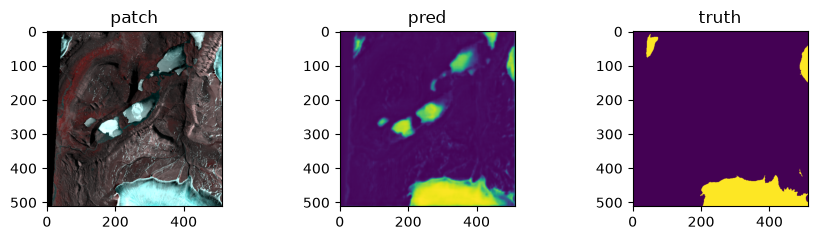

Ep20: tra-> Loss:0.146,Oa:0.973,Miou:0.930,                                 time:1.6s
Ep21: tra-> Loss:0.145,Oa:0.966,Miou:0.913, val-> Loss:0.137,Oa:0.961, Miou:0.895,time:4.0s
Ep22: tra-> Loss:0.156,Oa:0.967,Miou:0.916,                                 time:1.6s
Ep23: tra-> Loss:0.150,Oa:0.948,Miou:0.879, val-> Loss:0.116,Oa:0.961, Miou:0.894,time:4.1s
Ep24: tra-> Loss:0.142,Oa:0.966,Miou:0.904,                                 time:1.6s
Ep25: tra-> Loss:0.133,Oa:0.964,Miou:0.902, val-> Loss:0.128,Oa:0.962, Miou:0.897,time:4.1s
Ep26: tra-> Loss:0.161,Oa:0.962,Miou:0.898,                                 time:1.7s
Ep27: tra-> Loss:0.165,Oa:0.962,Miou:0.912, val-> Loss:0.129,Oa:0.961, Miou:0.894,time:4.1s
Ep28: tra-> Loss:0.113,Oa:0.978,Miou:0.934,                                 time:1.6s
Ep29: tra-> Loss:0.150,Oa:0.971,Miou:0.923, val-> Loss:0.109,Oa:0.961, Miou:0.894,time:4.2s
Ep30: tra-> Loss:0.118,Oa:0.975,Miou:0.943,                                 time:1.7s
Ep31: tra-> Loss:0.125,O

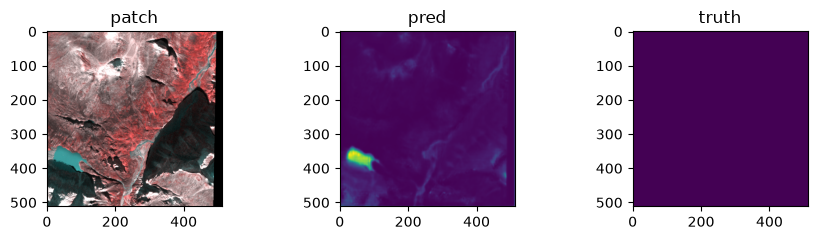

Ep40: tra-> Loss:0.105,Oa:0.974,Miou:0.929,                                 time:1.7s
Ep41: tra-> Loss:0.091,Oa:0.977,Miou:0.942, val-> Loss:0.100,Oa:0.963, Miou:0.900,time:4.0s
Ep42: tra-> Loss:0.109,Oa:0.970,Miou:0.914,                                 time:1.7s
Ep43: tra-> Loss:0.123,Oa:0.968,Miou:0.911, val-> Loss:0.124,Oa:0.962, Miou:0.898,time:4.0s
Ep44: tra-> Loss:0.156,Oa:0.955,Miou:0.881,                                 time:1.6s
Ep45: tra-> Loss:0.131,Oa:0.959,Miou:0.887, val-> Loss:0.120,Oa:0.964, Miou:0.901,time:4.0s
Ep46: tra-> Loss:0.120,Oa:0.949,Miou:0.873,                                 time:1.6s
Ep47: tra-> Loss:0.092,Oa:0.979,Miou:0.943, val-> Loss:0.096,Oa:0.963, Miou:0.901,time:4.1s
Ep48: tra-> Loss:0.116,Oa:0.969,Miou:0.923,                                 time:1.7s
Ep49: tra-> Loss:0.096,Oa:0.970,Miou:0.925, val-> Loss:0.090,Oa:0.964, Miou:0.902,time:4.1s
Ep50: tra-> Loss:0.094,Oa:0.970,Miou:0.916,                                 time:1.7s
Ep51: tra-> Loss:0.102,O

In [ ]:
device = torch.device('cuda:0') 
metrics = train_loops(model=model, 
                epoches=300,  
                loss_fn=loss_bce,  
                optimizer=optimizer,  
                tra_loader=tra_loader,  
                val_loader=val_loader,  
                # lr_scheduler=lr_scheduler,  
                device=device)  


In [ ]:
# # model saving 
# path_save = f'model/trained/{model_name}_weights.pth'
# torch.save(model.state_dict(), path_save)     ## save weights of the trained model 
# # # model.load_state_dict(torch.load(path_save, weights_only=True))  ## load the weights of the trained model
# # # ## metrics saving  
# path_metrics = f'model/trained/{model_name}_metrics.csv'    
# # path_metrics = f'model/trained/patch-{patch_size}/{model_name}_metrics_1.csv'    
# metrics_df = pd.DataFrame(metrics)
# metrics_df.to_csv(path_metrics, index=False, sep=',')
